# 3 — Baselines estadísticos: SARIMA y SARIMAX

**Entrada:** `dataset_modelado.csv`, `harmonie_crudo.csv`
**Salida:** `baselines_predicciones.parquet` + `baselines_metricas.csv`

Cubre el objetivo 2 del Anexo I en su parte estadística: *SARIMA como baseline estadístico*.

| Baseline | Qué usa | Por qué está |
|---|---|---|
| **HARMONIE bruto** | `H_vel` | El sistema operativo actual. Es a quien hay que superar |
| **SARIMA** | Solo `obs_vel` | Baseline estadístico clásico del Anexo |
| **SARIMAX** | `obs_vel` + `H_vel` exógena | El baseline **fuerte**: corrección estadística del modelo físico |

SARIMAX es el que de verdad exige: un SARIMA puro solo ve el pasado del anemómetro, y con
`H_vel` como exógena se convierte en un corrector del modelo físico — justo lo que harán los
modelos de ML. La comparación es honesta.

> **Persistencia y climatología quedan fuera de este análisis.** Son cotas triviales sin
> interés metodológico una vez que HARMONIE bruto y SARIMA ya están; no las consume ningún
> notebook posterior (4, 5, 6 solo leen `HARMONIE bruto`, `SARIMA` y `SARIMAX (+HARMONIE)`
> de `baselines_metricas.csv`).

## Advertencia metodológica

SARIMA necesita una serie **continua**. El dataset tiene varios tramos separados por huecos;
concatenarlos con fechas artificiales inventaría continuidad. Por eso los parámetros se
ajustan sobre el tramo de entrenamiento más largo, y la evaluación walk-forward recorre
**todos los tramos** con longitud suficiente, reiniciando el estado del filtro en cada uno.

> Los modelos de ML y DL usarán el dataset completo: al comparar entre notebooks hay que
> tener presente que aquí las cifras son de un subconjunto.

## Desventaja estructural de SARIMA

SARIMA predice **recursivamente**: para un horizonte de 12 h encadena 12 pasos y el error se
acumula. Los modelos de ML se entrenan **directamente** sobre el horizonte objetivo. No es
que SARIMA sea peor modelo: resuelve el problema de otra forma.

In [1]:
import warnings; warnings.filterwarnings('ignore')
from pathlib import Path
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_absolute_error, mean_squared_error

RUTA       = Path('.')
LATENCIA   = 4
HORIZONTES = list(range(1, 13))
K_FOURIER  = 3        # armónicos para la estacionalidad diaria
TEST_FRAC  = 0.4      # el 40% final: con un AR(3) sobran datos para entrenar
MIN_TRAMO  = 300      # longitud mínima de un tramo para ser evaluable
WARMUP     = 72        # horas para inicializar el estado del filtro en cada tramo
OBJ = 'obs_vel'
plt.rcParams['figure.figsize'] = (12, 4)

base  = pd.read_csv(RUTA/'dataset_modelado.csv', index_col='ts', parse_dates=['ts'])
crudo = pd.read_csv(RUTA/'harmonie_crudo.csv', parse_dates=['valida', 'pasada'])
crudo['V'] = np.hypot(crudo.WSPE, crudo.WSPN)

# Se usan TODOS los tramos con longitud suficiente (no solo el más largo), reiniciando
# el estado del filtro en cada uno: usar solo el más largo dejaba muestras de ~30h a
# horizontes altos, demasiado poco para que el MAE signifique algo.
tam = base.tramo.value_counts()
TRAMOS = sorted(tam[tam >= MIN_TRAMO].index)
print(f'{len(TRAMOS)} tramos con >= {MIN_TRAMO} h  ->  {tam[TRAMOS].sum()} horas')

CORTE = base.index[int(len(base)*(1-TEST_FRAC))]      # corte cronológico train/test
print(f'Corte train/test: {CORTE}')

# Los parámetros de SARIMA se estiman sobre el tramo de ENTRENAMIENTO más largo
tr_part = base[(base.index < CORTE) & base.tramo.isin(TRAMOS)]
TRAMO_FIT = tr_part.tramo.value_counts().idxmax()
serie = tr_part[tr_part.tramo == TRAMO_FIT].sort_index().asfreq('h')
saltos = (serie.index.to_series().diff().dropna() != pd.Timedelta('1h')).sum()
print(f'Ajuste de parámetros sobre el tramo {TRAMO_FIT}: {len(serie)} h continuas '
      f'({serie.index.min()} -> {serie.index.max()}, discontinuidades: {saltos})')

y = serie[OBJ]

6 tramos con >= 300 h  ->  22978 horas
Corte train/test: 2021-09-02 20:00:00
Ajuste de parámetros sobre el tramo 464: 3896 h continuas (2020-03-25 08:00:00 -> 2020-09-03 15:00:00, discontinuidades: 0)


---
## 1. Estacionariedad y estacionalidad

**Estacionariedad** fija el orden de diferenciación `d`: ADF (H₀ = no estacionaria) y KPSS
(H₀ = estacionaria) son complementarios; cuando coinciden, la conclusión es sólida.

**Estacionalidad diaria.** SARIMA con `s=24` sitúa los términos estacionales en los retardos
24, 48… y el ajuste puede tardar más que todo el ML junto. La alternativa estándar es modelar
el ciclo diurno con **términos de Fourier** como variables exógenas: con 3 armónicos se
captura la forma del ciclo en 6 columnas, y el ajuste baja de minutos a segundos.

Los términos de Fourier se calculan a partir de la hora del día de cada observación (horas
desde una fecha fija), de modo que la fase es la misma en todos los tramos, empiecen a la
hora que empiecen.

In [2]:
for nombre, s in [('sin diferenciar', y), ('diferenciada d=1', y.diff().dropna())]:
    p_adf, p_kpss = adfuller(s, autolag='AIC')[1], kpss(s, regression='c', nlags='auto')[1]
    print(f'{nombre:20s}  ADF p={p_adf:.4f} ({"estacionaria" if p_adf<.05 else "NO estacionaria"})'
          f'   KPSS p={p_kpss:.4f} ({"NO estacionaria" if p_kpss<.05 else "estacionaria"})')

D_ORDEN = 0 if adfuller(y, autolag='AIC')[1] < .05 else 1
print(f'\nOrden de diferenciación elegido: d = {D_ORDEN} '
      '(el viento suele ser estacionario en media)')

def fourier(idx, periodo=24, K=K_FOURIER):
    """Armónicos de seno/coseno para modelar un ciclo de periodo dado.
    La fase se calcula a partir de la marca temporal (horas desde una fecha fija),
    no de la posición dentro del tramo: así una misma hora del día tiene el mismo
    valor en todos los tramos, empiecen a la hora que empiecen."""
    t = ((idx - pd.Timestamp('2000-01-01')) / pd.Timedelta(hours=1)).to_numpy()
    return pd.DataFrame(
        {f'{f.__name__}{k}': f(2*np.pi*k*t/periodo)
         for k in range(1, K+1) for f in (np.sin, np.cos)},
        index=idx)

FOUR = fourier(serie.index)
print(f'{FOUR.shape[1]} términos de Fourier: {list(FOUR.columns)}')

sin diferenciar       ADF p=0.0000 (estacionaria)   KPSS p=0.1000 (estacionaria)
diferenciada d=1      ADF p=0.0000 (estacionaria)   KPSS p=0.1000 (estacionaria)

Orden de diferenciación elegido: d = 0 (el viento suele ser estacionario en media)
6 términos de Fourier: ['sin1', 'cos1', 'sin2', 'cos2', 'sin3', 'cos3']


/var/folders/ph/99zbx7td50l50prg5ypq2rfc0000gn/T/ipykernel_24064/1906664799.py:2: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  p_adf, p_kpss = adfuller(s, autolag='AIC')[1], kpss(s, regression='c', nlags='auto')[1]
/var/folders/ph/99zbx7td50l50prg5ypq2rfc0000gn/T/ipykernel_24064/1906664799.py:2: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  p_adf, p_kpss = adfuller(s, autolag='AIC')[1], kpss(s, regression='c', nlags='auto')[1]


---
## 2. Selección de órdenes (p, q) por AIC

Búsqueda pequeña: la ACF del notebook 2 ya indicaba una estructura autorregresiva corta. Los
parámetros se estiman **una vez** sobre el tramo de ajuste y se reutilizan en todos los tramos
de test mediante `apply()`/`filter()` — reajustar por tramo daría modelos distintos y la
comparación entre horizontes dejaría de ser limpia.

In [3]:
resultados_aic = []
for p in [1, 2, 3]:
    for q in [0, 1, 2]:
        try:
            t0 = time.time()
            m = SARIMAX(y, exog=FOUR, order=(p, D_ORDEN, q),
                        trend='c', enforce_stationarity=False, enforce_invertibility=False)
            r = m.fit(disp=False)
            resultados_aic.append({'p': p, 'd': D_ORDEN, 'q': q,
                                   'AIC': r.aic, 'BIC': r.bic, 'seg': time.time()-t0})
        except Exception as e:
            print(f'  ({p},{D_ORDEN},{q}) falló: {type(e).__name__}')

aic = pd.DataFrame(resultados_aic).sort_values('AIC')
display(aic.round(1))
MEJOR = tuple(aic.iloc[0][['p', 'd', 'q']].astype(int))
print(f'Orden elegido por AIC: {MEJOR}')

res_base = SARIMAX(y, exog=FOUR, order=MEJOR, trend='c',
                   enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
print(f'Modelo base ajustado: AIC={res_base.aic:.0f}')

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


,p,d,q,AIC,BIC,seg
2,1,0,2,12084.6,12153.6,0.6
6,3,0,0,12084.6,12153.6,0.6
1,1,0,1,12085.2,12147.8,0.8
7,3,0,1,12086.3,12161.5,1.8
5,2,0,2,12086.5,12161.7,1.4
4,2,0,1,12086.8,12155.7,0.5
8,3,0,2,12086.8,12168.3,2.4
3,2,0,0,12094.5,12157.2,0.3
0,1,0,0,12231.9,12288.3,0.2


Orden elegido por AIC: (1, 0, 2)
Modelo base ajustado: AIC=12085


---
## 3. Validación walk-forward multi-tramo

Para evaluar un horizonte `H` hay que predecir `H` pasos desde cada origen y quedarse con el
último — no hacer un único pronóstico largo. `SARIMAXResults.apply()`/`.filter()` reaplican
los parámetros ya estimados a una serie nueva **sin reestimar**, lo que permite saltar de un
tramo a otro sin arrastrar el estado del filtro de Kalman a través de un hueco de días: se
usan las primeras `WARMUP` horas para inicializarlo, y desde ahí se avanza con
`append(..., refit=False)`.

HARMONIE entra como exógena con `lead >= H + LATENCIA` (misma regla del notebook 2), lo que
convierte SARIMA en SARIMAX: un corrector estadístico del modelo físico.

In [4]:
def harmonie_para(H):
    apto = crudo[crudo.lead >= H + LATENCIA].sort_values(['valida', 'pasada'])
    h = apto.groupby('valida')['V'].last().rename('H_vel')
    h.index.name = 'ts'
    return h.to_frame()

def walk_forward_multi(res_ajustado, H, exog_extra=None, etiqueta=''):
    """Recorre todos los tramos de test prediciendo H pasos desde cada origen."""
    preds, objetivos = [], []
    t0 = time.time()
    for tid in TRAMOS:
        g = base[(base.tramo == tid) & (base.index >= CORTE)].sort_index().asfreq('h')
        if len(g) < WARMUP + H + 20:
            continue
        X = fourier(g.index)
        if exog_extra is not None:
            X = X.join(exog_extra, how='left')
            cols = list(exog_extra.columns)
            if X[cols].isna().all().any():
                continue    # exógena sin cobertura en este tramo: no se puede evaluar
            X[cols] = X[cols].interpolate(limit_area='inside').ffill().bfill()
        yg = g[OBJ]
        try:
            modelo_tramo = SARIMAX(yg.iloc[:WARMUP], exog=X.iloc[:WARMUP], order=MEJOR, trend='c',
                                  enforce_stationarity=False, enforce_invertibility=False)
            estado = modelo_tramo.filter(res_ajustado.params)
        except Exception:
            continue

        for i in range(WARMUP, len(g) - H + 1):
            f = estado.forecast(steps=H, exog=X.iloc[i:i+H])
            preds.append(f.iloc[-1]); objetivos.append(g.index[i+H-1])
            estado = estado.append(yg.iloc[i:i+1], exog=X.iloc[i:i+1], refit=False)

    print(f'  {etiqueta:20s} H={H:>2}  {len(preds):>5} predicciones en {time.time()-t0:5.0f}s')
    return pd.Series(preds, index=pd.DatetimeIndex(objetivos), name=etiqueta)

te_global = base[base.index >= CORTE]
for H in [1, 6, 12]:
    h = harmonie_para(H)
    cob = te_global.index.isin(h.index).mean()
    print(f'H={H:>3}  lead_min={H+LATENCIA:>3}  cobertura del test: {100*cob:5.1f} %'
          + ('   <-- BAJA' if cob <= .8 else ''))

H=  1  lead_min=  5  cobertura del test: 100.0 %
H=  6  lead_min= 10  cobertura del test:  98.3 %
H= 12  lead_min= 16  cobertura del test:  94.8 %


---
## 4. Evaluación completa

Todos los modelos se evalúan sobre el **mismo índice**: la intersección de horas en las que
todos tienen predicción. Comparar MAE calculados sobre muestras distintas no significa nada
— es justo el error que hacía parecer que HARMONIE mejoraba al aumentar el horizonte.

In [5]:
def evaluar(y_real, y_pred, idx):
    m = pd.concat([y_real.reindex(idx).rename('real'),
                   y_pred.reindex(idx).rename('pred')], axis=1).dropna()
    if len(m) == 0:
        return {'MAE': np.nan, 'RMSE': np.nan, 'n': 0}
    return {'MAE': mean_absolute_error(m.real, m.pred),
            'RMSE': np.sqrt(mean_squared_error(m.real, m.pred)), 'n': len(m)}

y_todo = base[OBJ]
filas, predicciones = [], {}

for H in HORIZONTES:
    harm = harmonie_para(H)

    p_sarima = walk_forward_multi(res_base, H, etiqueta='SARIMA')
    X_fit = FOUR.join(harm.reindex(serie.index), how='left')
    if X_fit['H_vel'].isna().all():
        print(f'  H={H}: sin cobertura de HARMONIE en el tramo de ajuste; SARIMAX se omite')
        p_sarimax = pd.Series(dtype=float, name='SARIMAX')
    else:
        X_fit['H_vel'] = X_fit['H_vel'].interpolate(limit_area='inside').ffill().bfill()
        res_sarimax = SARIMAX(y, exog=X_fit, order=MEJOR, trend='c',
                              enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
        p_sarimax = walk_forward_multi(res_sarimax, H, exog_extra=harm, etiqueta='SARIMAX')

    idx_te = p_sarima.index      # horas efectivamente predichas
    modelos = {
        'HARMONIE bruto':      harm.H_vel.reindex(idx_te),
        'SARIMA':              p_sarima,
        'SARIMAX (+HARMONIE)': p_sarimax,
    }

    comun = idx_te
    for pred in modelos.values():
        comun = comun.intersection(pred.dropna().index)
    if len(comun) < 300:
        print(f'  H={H}: AVISO, muestra pequeña ({len(comun)} horas), métricas poco fiables')

    for nombre, pred in modelos.items():
        r = evaluar(y_todo, pred, comun)
        r.update({'H': H, 'modelo': nombre})
        filas.append(r)
        predicciones[(H, nombre)] = pred.reindex(comun)

tabla = pd.DataFrame(filas)[['H', 'modelo', 'MAE', 'RMSE', 'n']]
for H in HORIZONTES:
    sub = tabla[tabla.H == H]
    print(f'\n--- Horizonte {H} h  (n = {sub.n.iloc[0]} horas) ---')
    display(sub.sort_values('MAE').round(3).set_index('modelo')[['MAE', 'RMSE']])

preds_df = pd.concat([
    pred.rename('pred').to_frame()
        .assign(H=H, modelo=modelo, real=y_todo.reindex(pred.index))
        .reset_index().rename(columns={'index': 'ts'})
    for (H, modelo), pred in predicciones.items()
], ignore_index=True).dropna(subset=['real', 'pred'])
preds_df.to_parquet(RUTA/'baselines_predicciones.parquet', index=False)
tabla.to_csv(RUTA/'baselines_metricas.csv', index=False)
print(f'\nGuardado: baselines_predicciones.parquet ({len(preds_df)} filas), '
      f'baselines_metricas.csv ({len(tabla)} filas)')

  SARIMA               H= 1   9344 predicciones en   156s
  SARIMAX              H= 1   9344 predicciones en   182s
  SARIMA               H= 2   9342 predicciones en   167s
  SARIMAX              H= 2   9342 predicciones en   184s
  SARIMA               H= 3   9340 predicciones en   177s
  SARIMAX              H= 3   9340 predicciones en   185s
  SARIMA               H= 4   9338 predicciones en   184s
  SARIMAX              H= 4   9338 predicciones en   189s
  SARIMA               H= 5   9336 predicciones en   179s
  SARIMAX              H= 5   9336 predicciones en   184s
  SARIMA               H= 6   9334 predicciones en   186s
  SARIMAX              H= 6   9334 predicciones en   205s
  SARIMA               H= 7   9332 predicciones en   203s
  SARIMAX              H= 7   9332 predicciones en   219s
  SARIMA               H= 8   9330 predicciones en   207s
  SARIMAX              H= 8   9330 predicciones en   207s
  SARIMA               H= 9   9328 predicciones en   205s
  SARIMAX     

,MAE,RMSE
modelo,,
SARIMAX (+HARMONIE),0.792,1.116
SARIMA,0.799,1.135
HARMONIE bruto,2.751,3.522



--- Horizonte 2 h  (n = 9341 horas) ---


,MAE,RMSE
modelo,,
SARIMAX (+HARMONIE),1.182,1.637
SARIMA,1.239,1.723
HARMONIE bruto,2.756,3.532



--- Horizonte 3 h  (n = 9339 horas) ---


...


--- Horizonte 11 h  (n = 8950 horas) ---


,MAE,RMSE
modelo,,
SARIMAX (+HARMONIE),2.720,3.443
HARMONIE bruto,2.790,3.558
SARIMA,2.997,3.825



--- Horizonte 12 h  (n = 8901 horas) ---


,MAE,RMSE
modelo,,
HARMONIE bruto,2.795,3.560
SARIMAX (+HARMONIE),2.802,3.532
SARIMA,3.108,3.947



Guardado: baselines_predicciones.parquet (329652 filas), baselines_metricas.csv (36 filas)


H,1,2,3,4,5,6,7,8,9,10,11,12
modelo,,,,,,,,,,,,
SARIMAX (+HARMONIE),0.792,1.182,1.431,1.647,1.829,2.023,2.168,2.362,2.465,2.600,2.720,2.802
SARIMA,0.799,1.239,1.551,1.811,2.037,2.240,2.415,2.582,2.731,2.867,2.997,3.108
HARMONIE bruto,2.751,2.756,2.764,2.775,2.778,2.780,2.785,2.791,2.791,2.790,2.790,2.795


figura guardada: figuras/baselines.pdf


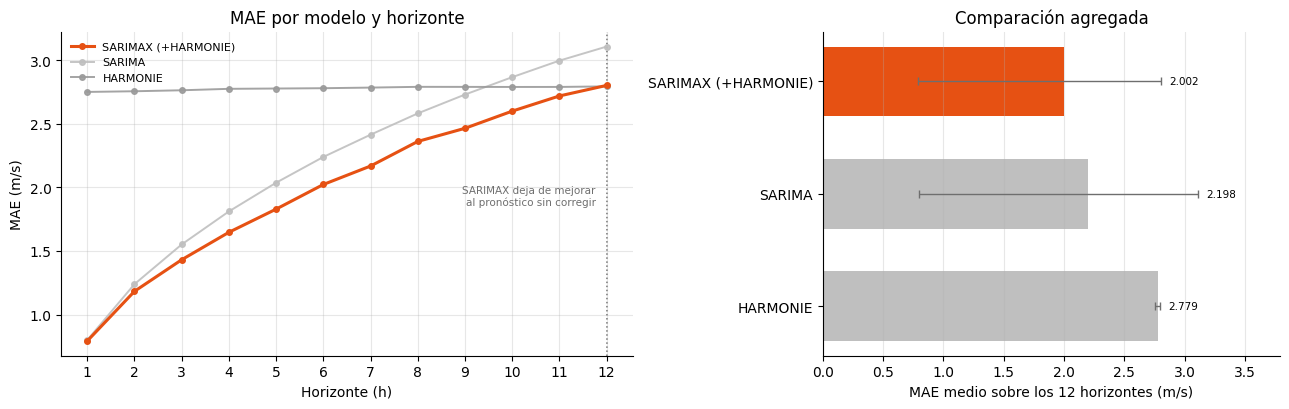

SARIMA vs SARIMAX: cuánta información añade el modelo físico a un marco estadístico.
Degradación con el horizonte: SARIMA cae rápido (error recursivo acumulado),
SARIMAX se sostiene mejor gracias a la exógena.


In [6]:
piv = tabla.pivot(index='modelo', columns='H', values='MAE')
piv = piv.loc[piv.mean(axis=1).sort_values().index]
display(piv.round(3))

# --- Resumen agregado --------------------------------------------------------
# Mismo criterio que en la selección de familias de ML: MAE medio sobre los doce
# horizontes, con el rango entre horizontes como medida de estabilidad.
resumen_base = pd.DataFrame({
    'MAE_medio': piv.mean(axis=1),
    'MAE_min':   piv.min(axis=1),
    'MAE_max':   piv.max(axis=1),
}).sort_values('MAE_medio')
GANADOR = resumen_base.index[0]

ETIQUETA = {'HARMONIE bruto': 'HARMONIE', 'SARIMA': 'SARIMA',
            'SARIMAX (+HARMONIE)': 'SARIMAX (+HARMONIE)'}
etq = lambda m: ETIQUETA.get(m, m)

# --- FIGURA ------------------------------------------------------------------
NARANJA = '#E65113'   # naranja corporativo del documento
GRIS    = '#6E6E6E'

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2),
                         gridspec_kw={'width_ratios': [1.25, 1]})

# (a) evolución con el horizonte: revela si algún baseline depende del plazo
grises = ['#BFBFBF', '#9A9A9A', '#7A7A7A', '#4A4A4A']
i_gris = 0
for modelo in resumen_base.index:
    if modelo == GANADOR:
        est = dict(color=NARANJA, lw=2.2, marker='o', zorder=5)
    else:
        est = dict(color=grises[i_gris % len(grises)], lw=1.4, marker='o', alpha=.9)
        i_gris += 1
    axes[0].plot(piv.columns, piv.loc[modelo],
                 markersize=4, label=etq(modelo), **est)
axes[0].set_xlabel('Horizonte (h)'); axes[0].set_ylabel('MAE (m/s)')
axes[0].set_title('MAE por modelo y horizonte')
axes[0].set_xticks(list(piv.columns))
axes[0].legend(fontsize=8, frameon=False)
axes[0].grid(alpha=.3)

# Se señala dónde SARIMAX deja de mejorar al pronóstico sin corregir: es el
# efecto de la predicción recursiva, y conviene que la figura lo haga explícito.
if {'SARIMAX (+HARMONIE)', 'HARMONIE bruto'} <= set(piv.index):
    peor = [h for h in piv.columns
            if piv.loc['SARIMAX (+HARMONIE)', h] > piv.loc['HARMONIE bruto', h]]
    if peor:
        h_cruce = min(peor)
        axes[0].axvline(h_cruce, color=GRIS, ls=':', lw=1.1, zorder=0)
        axes[0].annotate('SARIMAX deja de mejorar\nal pronóstico sin corregir',
                         xy=(h_cruce, axes[0].get_ylim()[1] * .60),
                         xytext=(-8, 0), textcoords='offset points',
                         ha='right', va='center', fontsize=7.5, color=GRIS)

# (b) MAE medio, con el rango entre horizontes como barra de error
orden = resumen_base.index[::-1]
colores = [NARANJA if m == GANADOR else '#BFBFBF' for m in orden]
err = np.vstack([(resumen_base.loc[orden, 'MAE_medio'] - resumen_base.loc[orden, 'MAE_min']).values,
                 (resumen_base.loc[orden, 'MAE_max'] - resumen_base.loc[orden, 'MAE_medio']).values])
etiquetas = [etq(m) for m in orden]
axes[1].barh(etiquetas, resumen_base.loc[orden, 'MAE_medio'], xerr=err,
             color=colores, height=.62, error_kw=dict(ecolor=GRIS, capsize=3, lw=1))
axes[1].set_xlabel(f'MAE medio sobre los {piv.shape[1]} horizontes (m/s)')
axes[1].set_title('Comparación agregada')
axes[1].grid(axis='x', alpha=.3); axes[1].grid(axis='y', visible=False)
for m, e in zip(orden, etiquetas):
    axes[1].annotate(f"{resumen_base.loc[m, 'MAE_medio']:.3f}",
                     xy=(resumen_base.loc[m, 'MAE_max'], e),
                     xytext=(6, 0), textcoords='offset points',
                     va='center', fontsize=7.5)
axes[1].set_xlim(0, resumen_base.MAE_max.max() * 1.22)

for ax in axes:
    for lado in ('top', 'right'):
        ax.spines[lado].set_visible(False)

plt.tight_layout()

NOMBRE = 'baselines'

# --- Exportación para la memoria ---------------------------------------------
from pathlib import Path
Path('figuras').mkdir(exist_ok=True)
for _fmt in ('pdf', 'png'):
    fig.savefig(f'figuras/{NOMBRE}.{_fmt}', format=_fmt, dpi=400, bbox_inches='tight')
print(f'figura guardada: figuras/{NOMBRE}.pdf')

plt.show()

print('SARIMA vs SARIMAX: cuánta información añade el modelo físico a un marco estadístico.')
print('Degradación con el horizonte: SARIMA cae rápido (error recursivo acumulado),')
print('SARIMAX se sostiene mejor gracias a la exógena.')


figura guardada: figuras/baselines_mejora.pdf


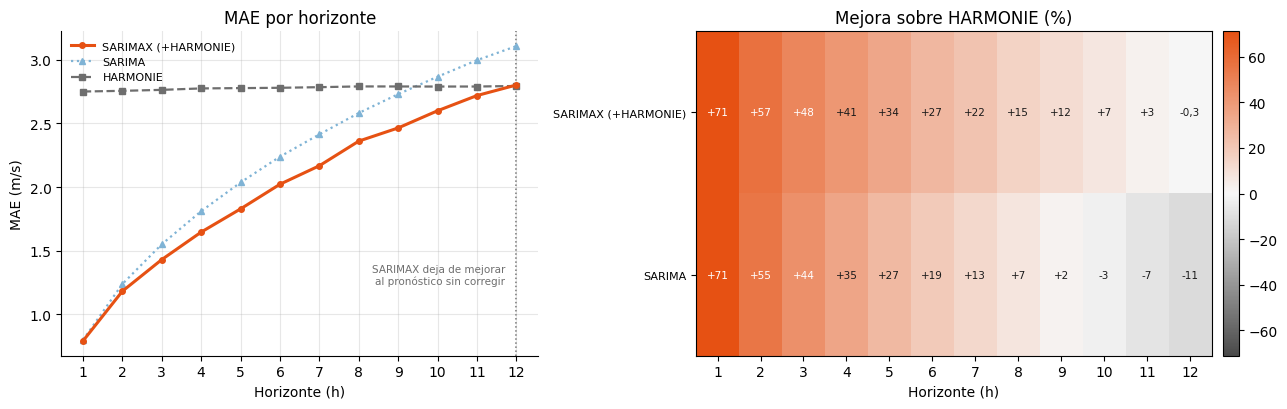

Mejora sobre HARMONIE (%):
H                      1     2     3     4     5     6     7     8     9    10   11    12
modelo                                                                                   
SARIMAX (+HARMONIE)  71.2  57.1  48.2  40.7  34.2  27.2  22.2  15.4  11.7  6.8  2.5  -0.3
SARIMA               70.9  55.1  43.9  34.7  26.7  19.4  13.3   7.5   2.2 -2.8 -7.4 -11.2


In [7]:
# --- FIGURA 5.1: MAE por horizonte y mejora sobre HARMONIE ---
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm

piv = (pd.read_csv('baselines_metricas.csv')
         .pivot(index='modelo', columns='H', values='MAE'))

NARANJA, GRIS, AZUL = '#E65113', '#6E6E6E', '#7FB3D5'
MODELOS = ['SARIMAX (+HARMONIE)', 'SARIMA']

h_bruto = piv.loc['HARMONIE bruto']
mejora = piv.loc[MODELOS].rsub(h_bruto, axis=1).div(h_bruto, axis=1) * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2),
                         gridspec_kw={'width_ratios': [1, 1.15]})

# (a) MAE por horizonte
estilos = {
    'SARIMAX (+HARMONIE)': dict(color=NARANJA, ls='-',  marker='o', lw=2.2, zorder=5),
    'SARIMA':              dict(color=AZUL,    ls=':',  marker='^', lw=1.6),
    'HARMONIE bruto':      dict(color=GRIS,    ls='--', marker='s', lw=1.6),
}
for m, est in estilos.items():
    axes[0].plot(piv.columns, piv.loc[m], markersize=4,
                 label=m.replace(' bruto', ''), **est)

# Horizonte a partir del cual SARIMAX deja de mejorar al pronóstico sin corregir
peor = [h for h in piv.columns
        if piv.loc['SARIMAX (+HARMONIE)', h] > piv.loc['HARMONIE bruto', h]]
if peor:
    h_cruce = min(peor)
    y0, y1 = axes[0].get_ylim()
    axes[0].axvline(h_cruce, color=GRIS, ls=':', lw=1.1, zorder=0)
    axes[0].annotate('SARIMAX deja de mejorar\nal pronóstico sin corregir',
                     xy=(h_cruce, y0 + .25*(y1 - y0)), xytext=(-8, 0),
                     textcoords='offset points', ha='right', va='center',
                     fontsize=7.5, color=GRIS)

axes[0].set_xlabel('Horizonte (h)'); axes[0].set_ylabel('MAE (m/s)')
axes[0].set_title('MAE por horizonte')
axes[0].set_xticks(list(piv.columns))
axes[0].legend(fontsize=8, frameon=False, loc='upper left')
axes[0].grid(alpha=.3)
for lado in ('top', 'right'):
    axes[0].spines[lado].set_visible(False)

# (b) Mejora porcentual sobre HARMONIE: naranja si mejora, gris si empeora
cmap = LinearSegmentedColormap.from_list('tfm', ['#4A4A4A', '#F7F7F7', NARANJA])
lim = np.abs(mejora.values).max()
im = axes[1].imshow(mejora.values, cmap=cmap, norm=TwoSlopeNorm(0, -lim, lim),
                    aspect='auto')
axes[1].set_xticks(range(mejora.shape[1]))
axes[1].set_xticklabels(mejora.columns)
axes[1].set_yticks(range(mejora.shape[0]))
axes[1].set_yticklabels(mejora.index, fontsize=8)
for i in range(mejora.shape[0]):
    for j in range(mejora.shape[1]):
        v = mejora.iat[i, j]
        texto = (f'{v:+.0f}' if abs(v) >= .5 else f'{v:+.1f}').replace('.', ',')
        axes[1].text(j, i, texto, ha='center', va='center', fontsize=7.5,
                     color='white' if abs(v) > .6*lim else '#1A1A1A')
axes[1].set_xlabel('Horizonte (h)')
axes[1].set_title('Mejora sobre HARMONIE (%)')
plt.colorbar(im, ax=axes[1], fraction=.04, pad=.02)

plt.tight_layout()

NOMBRE = 'baselines_mejora'
Path('figuras').mkdir(exist_ok=True)
for _fmt in ('pdf', 'png'):
    fig.savefig(f'figuras/{NOMBRE}.{_fmt}', format=_fmt, dpi=400, bbox_inches='tight')
print(f'figura guardada: figuras/{NOMBRE}.pdf')
plt.show()

print('Mejora sobre HARMONIE (%):')
print(mejora.round(1).to_string())

---
## 5. Ejemplo de predicción: un episodio concreto

Las métricas agregadas de las secciones anteriores resumen miles de horas, pero
ocultan cómo se comporta cada modelo en un episodio real. Esta sección reconstruye
un caso de uso operativo completo.

**Cómo se lee el ejemplo.** Se fija un *instante de decisión* $t_0$ y se
representan:

* Las **horas previas** a $t_0$: observaciones ya disponibles: es la información
  con la que cuenta el operador al decidir, y la que alimenta la parte
  autorregresiva de los modelos.
* Las **12 horas siguientes** a $t_0$: lo que cada modelo pronostica para
  $t_0+1,\ldots,t_0+12$, junto con lo que realmente ocurrió.

Es importante entender que cada punto de la curva de predicción proviene de un
modelo distinto: el valor en $t_0+6$ es la predicción del modelo entrenado a
horizonte 6~h, no un paso intermedio de una predicción a 12~h. Esto refleja
exactamente el uso operativo, en el que cada horizonte tiene su propio modelo.

8899 instantes de decisión con predicción completa en los 12 horizontes

Instante de decisión: 2022-04-04 14:00:00
Recorrido del viento en las 12 h siguientes: 6.3 m/s



,real,momento,H,HARMONIE bruto,SARIMA,SARIMAX (+HARMONIE),err HARMONIE,err SARIMA,err SARIMAX
ts,,,,,,,,,
2022-04-04 09:00:00,25.07,historia,0,NaN,NaN,NaN,NaN,NaN,NaN
2022-04-04 10:00:00,23.43,historia,0,NaN,NaN,NaN,NaN,NaN,NaN
2022-04-04 11:00:00,22.27,historia,0,NaN,NaN,NaN,NaN,NaN,NaN
2022-04-04 12:00:00,21.63,historia,0,NaN,NaN,NaN,NaN,NaN,NaN
2022-04-04 13:00:00,22.31,historia,0,NaN,NaN,NaN,NaN,NaN,NaN
2022-04-04 14:00:00,22.67,historia,0,NaN,NaN,NaN,NaN,NaN,NaN
2022-04-04 15:00:00,23.19,predicción,1,14.61,22.46,22.57,8.58,0.73,0.62
2022-04-04 16:00:00,23.21,predicción,2,17.41,22.06,22.89,5.80,1.16,0.33
2022-04-04 17:00:00,22.73,predicción,3,17.19,21.53,22.61,5.54,1.21,0.12


figura guardada: figuras/episodio_prediccion.pdf


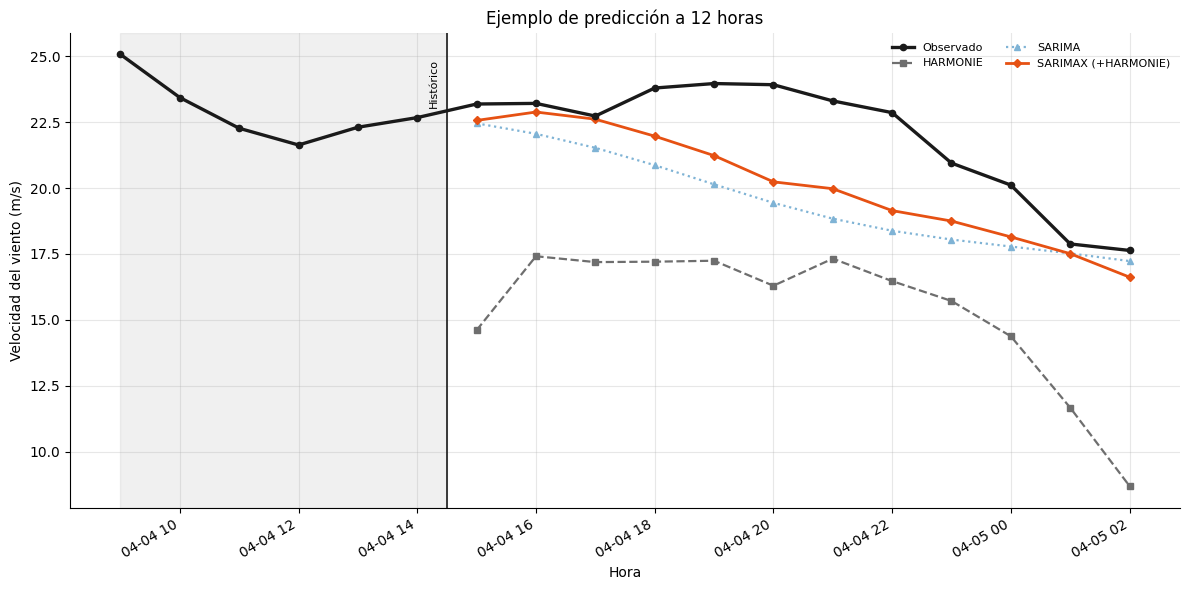

MAE en este episodio (12 h) frente al MAE medio global:
  HARMONIE               episodio  6.61 m/s | global  2.78 m/s
  SARIMA                 episodio  2.44 m/s | global  2.20 m/s
  SARIMAX (+HARMONIE)    episodio  1.83 m/s | global  2.00 m/s

(un episodio concreto puede desviarse mucho de la media: se muestra
 con propósito ilustrativo, no como evidencia de rendimiento)


In [8]:
# --- Configuración del ejemplo ------------------------------------------------
N_PREVIAS = 6       # horas de historia observada antes del instante de decisión
MODELOS_EJ = ['HARMONIE bruto', 'SARIMA', 'SARIMAX (+HARMONIE)']

NARANJA = '#E65113'   # naranja corporativo del documento
GRIS    = '#6E6E6E'

# Etiquetas para la leyenda. Se separan de las claves internas ('HARMONIE bruto',
# etc.), que deben conservarse porque indexan `predicciones` y filtran `tabla`.
ETIQUETA = {
    'HARMONIE bruto':      'HARMONIE',
    'SARIMA':              'SARIMA',
    'SARIMAX (+HARMONIE)': 'SARIMAX (+HARMONIE)',
}
ESTILO_EJ = {
    'real':                dict(color='#1A1A1A', ls='-',  marker='o', lw=2.4, zorder=5),
    'HARMONIE bruto':      dict(color=GRIS,      ls='--', marker='s', lw=1.6),
    'SARIMA':              dict(color='#7FB3D5', ls=':',  marker='^', lw=1.6),
    'SARIMAX (+HARMONIE)': dict(color=NARANJA,   ls='-',  marker='D', lw=2.0),
}

def horas_con_prediccion_completa():
    """Instantes de decisión t0 para los que TODOS los modelos tienen predicción
    en los 12 horizontes: solo entonces el ejemplo es comparable entre modelos."""
    candidatas = None
    for H in HORIZONTES:
        for m in MODELOS_EJ:
            if (H, m) not in predicciones:
                return pd.DatetimeIndex([])
            # una predicción válida para t0+H implica que t0 = ts - H horas
            t0 = predicciones[(H, m)].dropna().index - pd.Timedelta(hours=H)
            candidatas = t0 if candidatas is None else candidatas.intersection(t0)
    return candidatas.sort_values()

def construir_episodio(t0):
    """Historia previa + predicción de cada modelo por horizonte + valor real."""
    previas = pd.date_range(t0 - pd.Timedelta(hours=N_PREVIAS - 1), t0, freq='h')
    futuras = pd.date_range(t0 + pd.Timedelta(hours=1),
                            t0 + pd.Timedelta(hours=max(HORIZONTES)), freq='h')

    ep = pd.DataFrame(index=previas.append(futuras))
    ep.index.name = 'ts'
    ep['real'] = base[OBJ].reindex(ep.index)
    ep['momento'] = ['historia'] * len(previas) + ['predicción'] * len(futuras)
    ep['H'] = [0] * len(previas) + list(range(1, len(futuras) + 1))

    for m in MODELOS_EJ:
        col = []
        for H in ep.H:
            if H == 0:
                col.append(np.nan)
                continue
            serie = predicciones.get((H, m))
            ts_obj = t0 + pd.Timedelta(hours=H)
            col.append(serie.get(ts_obj, np.nan) if serie is not None else np.nan)
        ep[m] = col
    return ep

disponibles = horas_con_prediccion_completa()
print(f'{len(disponibles)} instantes de decisión con predicción completa '
      f'en los {len(HORIZONTES)} horizontes')

if len(disponibles) == 0:
    print('No hay ningún instante con predicción completa: se omite el ejemplo.')
else:
    # Se elige un episodio representativo: el de mayor recorrido de viento en las
    # 12 h siguientes, por ser el caso donde la calidad del pronóstico importa.
    # Cámbiese T0 por una fecha concreta para examinar otro episodio.
    recorrido = {}
    for t0 in disponibles:
        tramo = base[OBJ].reindex(pd.date_range(t0 + pd.Timedelta(hours=1),
                                                t0 + pd.Timedelta(hours=12), freq='h'))
        if tramo.notna().all():
            recorrido[t0] = tramo.max() - tramo.min()
    T0 = pd.Timestamp(2022, 4, 4, 14, 0, 0)

    ep = construir_episodio(T0)
    print(f'\nInstante de decisión: {T0}')
    print(f'Recorrido del viento en las 12 h siguientes: {recorrido.get(T0, float("nan")):.1f} m/s\n')

    tabla_ep = ep.copy()
    for m in MODELOS_EJ:
        tabla_ep[f'err {ETIQUETA.get(m, m).split()[0]}'] = (tabla_ep[m] - tabla_ep['real']).abs()
    display(tabla_ep.round(2))

    # --- FIGURA -------------------------------------------------------------
    fig, ax = plt.subplots(figsize=(12, 6))
    hist = ep[ep.momento == 'historia']
    fut  = ep[ep.momento == 'predicción']

    # Historia observada: continua con el futuro real para que la línea no se corte
    real_completo = ep['real']
    ax.plot(real_completo.index, real_completo.values, label='Observado',
            markersize=4.5, **ESTILO_EJ['real'])

    # Zona de historia sombreada: delimita qué sabía el operador al decidir. El
    # corte se sitúa a mitad de camino entre t0 y la primera hora predicha, de
    # modo que la separación caiga en el hueco entre ambas series y no sobre el
    # último punto observado, que todavía pertenece a la historia.
    CORTE_VISUAL = T0 + pd.Timedelta(minutes=30)
    ax.axvspan(hist.index[0], CORTE_VISUAL, color=GRIS, alpha=.10, zorder=0)
    ax.axvline(CORTE_VISUAL, color='#1A1A1A', lw=1.2, ls='-')
    ax.annotate('Histórico', xy=(CORTE_VISUAL, ax.get_ylim()[1]),
                xytext=(-6, -10), textcoords='offset points',
                ha='right', va='top', fontsize=8, rotation=90)

    for m in MODELOS_EJ:
        serie = fut[m]
        if serie.notna().any():
            ax.plot(serie.index, serie.values, label=ETIQUETA.get(m, m),
                    markersize=4.5, **ESTILO_EJ[m])


    ax.set_xlabel('Hora'); ax.set_ylabel('Velocidad del viento (m/s)')
    ax.set_title(f'Ejemplo de predicción a 12 horas')
    ax.legend(fontsize=8, frameon=False, ncol=2, loc='best')
    ax.grid(alpha=.3)
    for lado in ('top', 'right'):
        ax.spines[lado].set_visible(False)
    fig.autofmt_xdate(rotation=30, ha='right')

    # --- Exportación para la memoria -------------------------------------
    NOMBRE = 'episodio_prediccion'
    from pathlib import Path
    Path('figuras').mkdir(exist_ok=True)
    for _fmt in ('pdf', 'png'):
        fig.savefig(f'figuras/{NOMBRE}.{_fmt}', format=_fmt, dpi=400,
                    bbox_inches='tight')
    print(f'figura guardada: figuras/{NOMBRE}.pdf')

    plt.tight_layout(); plt.show()

    # --- Error de este episodio frente al error medio global ----------------
    print('MAE en este episodio (12 h) frente al MAE medio global:')
    for m in MODELOS_EJ:
        err_ep = (fut[m] - fut['real']).abs().mean()
        err_glob = tabla[tabla.modelo == m].MAE.mean()
        print(f'  {ETIQUETA.get(m, m):22s} episodio {err_ep:5.2f} m/s | '
              f'global {err_glob:5.2f} m/s')
    print('\n(un episodio concreto puede desviarse mucho de la media: se muestra')
    print(' con propósito ilustrativo, no como evidencia de rendimiento)')

---
## 6. Diagnóstico de residuos

Un modelo bien especificado deja residuos sin autocorrelación. Si queda estructura, los
órdenes elegidos se quedan cortos. Se diagnostica a H=12h, con HARMONIE como exógena.

figura guardada: figuras/diagnostico_residuos.pdf


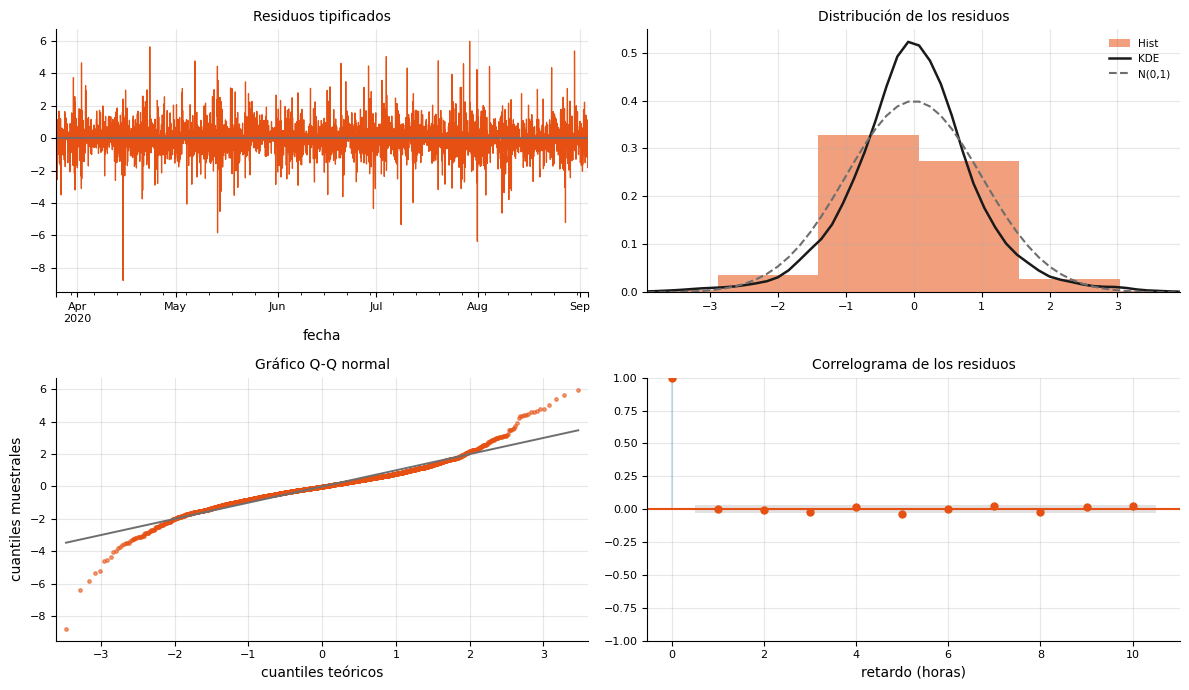

,lb_stat,lb_pvalue
12,20.6382,0.0559
24,28.1019,0.2558
48,59.8429,0.1173


Ljung-Box: p < 0,05 indica autocorrelación residual (modelo mal especificado)


In [9]:
H_REF = 12
harm = harmonie_para(H_REF)
X = FOUR.join(harm, how='left')
if X['H_vel'].isna().all():
    print(f'La exógena no cubre el tramo de ajuste a H={H_REF}; se diagnostica SARIMA sin exógena.')
    X = FOUR
else:
    X['H_vel'] = X['H_vel'].interpolate(limit_area='inside').ffill().bfill()

res_fin = SARIMAX(y, exog=X, order=MEJOR, trend='c',
                  enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)

# --- FIGURA: diagnóstico de residuos -----------------------------------------
NARANJA = '#E65113'   # naranja corporativo del documento
GRIS    = '#6E6E6E'
NEGRO   = '#1A1A1A'

# plot_diagnostics no admite colores como argumento: dibuja los cuatro paneles
# con la paleta por defecto de statsmodels y hay que recolorearlos después,
# recorriendo los artistas de cada eje.
fig = res_fin.plot_diagnostics(figsize=(12, 7))
ax_resid, ax_hist, ax_qq, ax_corr = fig.axes

# (a) Residuos tipificados: serie en naranja
for linea in ax_resid.get_lines():
    linea.set_color(NARANJA); linea.set_linewidth(.9)
ax_resid.set_title('Residuos tipificados')

# (b) Histograma: barras en naranja; las dos curvas de densidad (KDE estimada y
#     normal teórica) se distinguen por color y estilo, no solo por la leyenda.
for parche in ax_hist.patches:
    parche.set_facecolor(NARANJA); parche.set_alpha(.55); parche.set_edgecolor('none')
estilos_densidad = [dict(color=NEGRO, ls='-', lw=1.8), dict(color=GRIS, ls='--', lw=1.5)]
for linea, est in zip(ax_hist.get_lines(), estilos_densidad):
    linea.set(**est)
ax_hist.set_title('Distribución de los residuos')
if ax_hist.get_legend():
    ax_hist.legend(fontsize=7.5, frameon=False)

# (c) Gráfico Q-Q. statsmodels lo dibuja con dos Line2D: la primera son los
#     puntos (marcador 'o' sin línea) y la segunda la recta de referencia. Se
#     distinguen por el marcador, normalizando el valor porque matplotlib emplea
#     indistintamente None y la cadena 'None' para indicar su ausencia.
for coleccion in ax_qq.collections:          # por si alguna versión usa scatter
    coleccion.set_facecolor(NARANJA); coleccion.set_edgecolor('none')
    coleccion.set_alpha(.55); coleccion.set_sizes([6])
for linea in ax_qq.get_lines():
    if str(linea.get_marker()) in ('None', '', 'none'):
        linea.set(color=GRIS, lw=1.4)                     # recta de referencia
    else:
        # En una línea con marcadores, set_color() NO afecta al relleno del
        # marcador: hay que fijar markerfacecolor y markeredgecolor de forma
        # explícita, o los puntos conservan el azul por defecto.
        linea.set(color=NARANJA, markerfacecolor=NARANJA, markeredgecolor=NARANJA,
                  marker='o', markersize=2.5, alpha=.55, linestyle='None')
ax_qq.set_title('Gráfico Q-Q normal')
ax_qq.set_xlabel('cuantiles teóricos'); ax_qq.set_ylabel('cuantiles muestrales')

# (d) Correlograma: barras verticales y marcadores en naranja, banda de
#     significación en gris para que no compita visualmente con los datos.
for linea in ax_corr.get_lines():
    linea.set(color=NARANJA, markerfacecolor=NARANJA, markeredgecolor=NARANJA)
for coleccion in ax_resid.collections:      # relleno del panel de residuos
    coleccion.set_facecolor(NARANJA); coleccion.set_alpha(.5)
for coleccion in ax_corr.collections:
    coleccion.set_facecolor(GRIS); coleccion.set_alpha(.20)
ax_corr.set_title('Correlograma de los residuos')
ax_corr.set_xlabel('retardo (horas)')
ax_resid.set_xlabel('fecha')

for ax in fig.axes:
    ax.grid(alpha=.3)
    ax.tick_params(labelsize=8)
    ax.title.set_fontsize(10)
    for lado in ('top', 'right'):
        ax.spines[lado].set_visible(False)

NOMBRE = 'diagnostico_residuos'

# --- Exportación para la memoria ---------------------------------------------
from pathlib import Path
Path('figuras').mkdir(exist_ok=True)
for _fmt in ('pdf', 'png'):
    fig.savefig(f'figuras/{NOMBRE}.{_fmt}', format=_fmt, dpi=400, bbox_inches='tight')
print(f'figura guardada: figuras/{NOMBRE}.pdf')
plt.tight_layout(); plt.show()

lb = acorr_ljungbox(res_fin.resid, lags=[12, 24, 48], return_df=True)
display(lb.round(4))
print('Ljung-Box: p < 0,05 indica autocorrelación residual (modelo mal especificado)')

---
## 7. Conclusiones

**Qué mirar en la tabla:**

* **SARIMAX frente a HARMONIE bruto** — mide si la corrección estadística funciona. Es la
  misma pregunta que responderá el ML, pero con un modelo lineal clásico: da la referencia
  contra la que juzgar si merece la pena la complejidad del ML.
* **SARIMA frente a SARIMAX** — cuantifica cuánta información añade el modelo físico a un
  marco puramente estadístico.
* **Degradación con el horizonte** — ambos se degradan por el error recursivo acumulado. La
  exógena retrasa la degradación de SARIMAX, que alcanza al pronóstico bruto en H = 12
  (SARIMA ya lo supera en H = 10), pero no la evita.

**Para la memoria.** Estos baselines definen el listón: un modelo de ML que mejore un 2% a
SARIMAX no justifica la complejidad añadida; uno que mejore un 20%, sí.

**Limitaciones a declarar:**

1. Evaluado sobre los tramos con longitud suficiente, no sobre el dataset completo.
2. Los parámetros se ajustan una vez y solo se actualiza el estado (`refit=False`).
3. Estacionalidad diaria con Fourier en lugar de términos SARIMA estacionales.
4. SARIMA predice recursivamente; el ML se entrena directo sobre el horizonte.

**Ficheros generados**, consumidos por los notebooks 4 (ML), 5 (DL) y 6 (Diebold-Mariano):

| Fichero | Contiene |
|---|---|
| `baselines_predicciones.parquet` | predicciones hora a hora de HARMONIE bruto, SARIMA y SARIMAX |
| `baselines_metricas.csv` | MAE/RMSE por modelo y horizonte |

**Siguiente:** notebook 4 — modelos de Machine Learning.